In [3]:
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.utils import to_networkx

dataset = BA2MotifDataset(root="../data")
data = dataset[42]
g = to_networkx(data, to_undirected=True)

In [4]:
import networkx as nx
from collections import defaultdict
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt


# For each node, count the number of shortest paths of length k that pass through it.
# Normalize by the total number of shortest paths of length k.
def k_hop_centrality(g, k, normalize=True):
    centrality = defaultdict(int)
    normalizer = 0
    for _, paths_dict in nx.all_pairs_all_shortest_paths(g):
        for _, paths in paths_dict.items():
            for path in paths:
                if len(path) - 1 <= k:  # path length in edges
                    normalizer += 1
                    for node in path:
                        centrality[node] += 1
    if normalize:
        normalizer = max(1, normalizer)  # Avoid division by zero
        centrality = {node: count / normalizer for node, count in centrality.items()}
    return dict(centrality)


def compare_node_colorings(g, coloring_1, coloring_2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    pos = nx.spring_layout(g)
    for coloring, ax in zip([coloring_1, coloring_2], [ax1, ax2]):
        color_map = [coloring[node] for node in g.nodes()]
        sm = ScalarMappable(cmap="viridis", norm=Normalize(vmin=0, vmax=max(color_map)))
        sm.set_array([])
        nx.draw(g, pos, node_color=color_map, ax=ax, with_labels=True)
        fig.colorbar(sm, ax=ax)

25


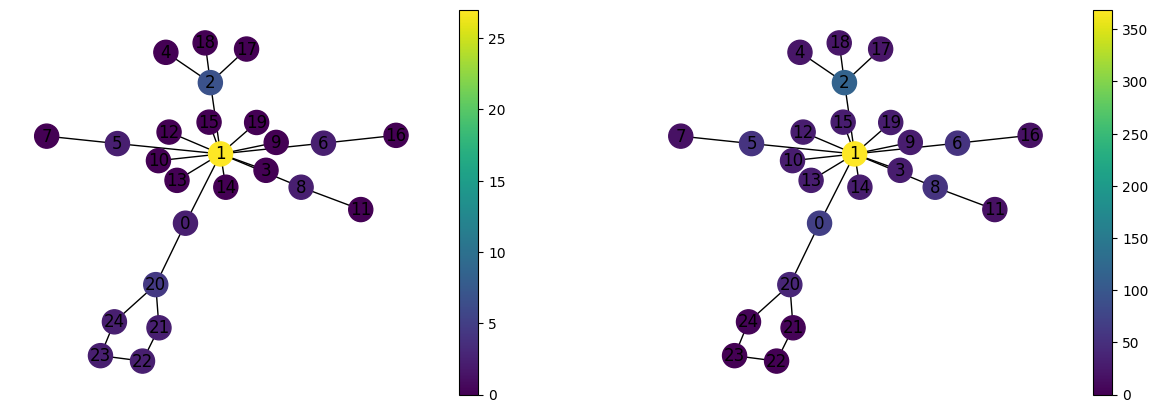

In [ ]:
c1 = k_hop_centrality(g, 1, normalize=False)
c3 = k_hop_centrality(g, 3, normalize=False)

compare_node_colorings(g, c1, c3)

In [14]:
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from torch_geometric.datasets import BA2MotifDataset
from pytorch_lightning import Trainer

import pandas as pd
from bcosgnn.models import BinaryClassifierGNN
from bcosgnn.bcos_gnn import GNNCls
from bcosgnn.data.load_dataset import load_dataset, NamedDataset
from bcosgnn.data.splits import split_random

from torch_geometric.utils import to_networkx
import networkx as nx

import torch

In [19]:
model = BinaryClassifierGNN.load_from_checkpoint("../models/bcosgnn_motif_d0.5.pt")
model.eval()

dataset = BA2MotifDataset("../data")

_, _, test_idx = split_random(dataset)
test_dataset = dataset[test_idx]
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

explanations = []
for data in test_dataloader:
    explanation = model.explain(data)
    explanations.append(explanation["x"]["contribution_map"].sum(1))

c:\Projects\Python\bcosgnn\.venv\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


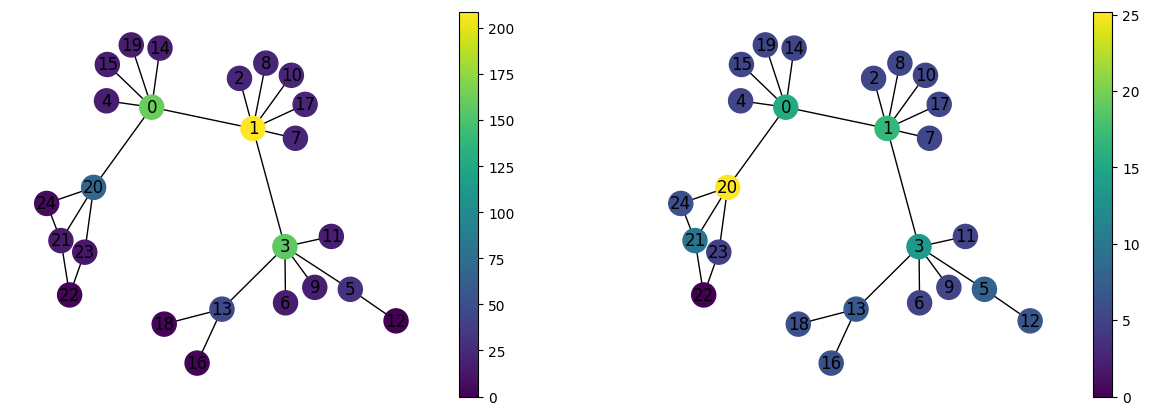

In [38]:
idx = 10
g = to_networkx(test_dataset[idx], to_undirected=True)
c1 = k_hop_centrality(g, 3, normalize=False)
c2 = explanations[idx].detach().numpy()
compare_node_colorings(g, c1, c2)